In [2]:
from pydpeet.process.analyze.extract.field_data_loader import load_field_data_csv

df_field = load_field_data_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/input_data/Felddaten/vin38.csv")

print(df_field.shape, df_field["Test_Time[s]"].iloc[-1] / 86400, "Tage")
df_field.head()


(4132658, 14) 939.7630787037037 Tage


,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],Capacity[Ah],SOC,PackVoltage[V]
0,FieldData,0,3.757958,-126.3,31.5,0.0,1970-01-01 00:00:11,NaN,NaN,NaN,NaN,-0.000000,0.37,360.7
1,FieldData,0,3.758667,-126.3,32.0,10.0,1970-01-01 00:00:21,NaN,NaN,NaN,NaN,-0.350833,0.37,360.8
2,FieldData,0,3.760146,-126.1,32.0,20.0,1970-01-01 00:00:31,NaN,NaN,NaN,NaN,-0.701111,0.37,360.9
3,FieldData,0,3.761354,-126.1,32.0,30.0,1970-01-01 00:00:41,NaN,NaN,NaN,NaN,-1.051389,0.37,361.0
4,FieldData,0,3.762469,-126.2,32.0,40.0,1970-01-01 00:00:51,NaN,NaN,NaN,NaN,-1.401944,0.38,361.1


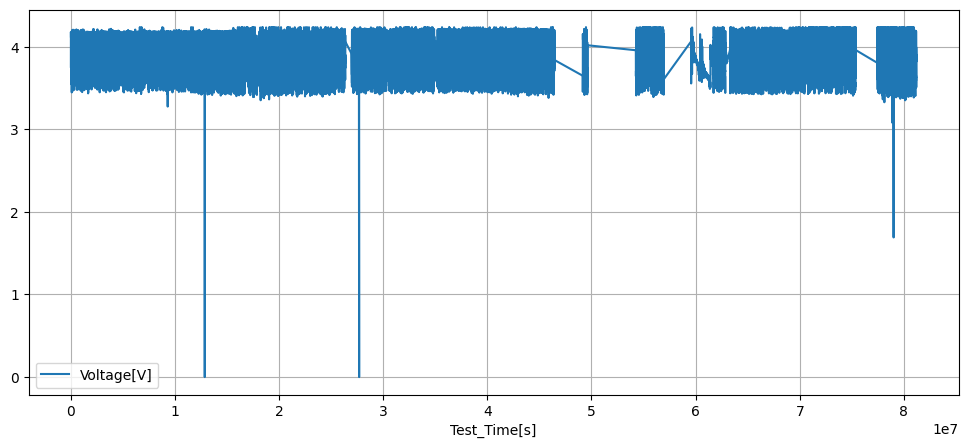

In [3]:
import matplotlib.pyplot as plt
df_field.plot(x="Test_Time[s]", y="Voltage[V]", figsize=(12, 5), grid=True)
plt.show()

In [4]:
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

pauses  = extract_pauses(df_field, min_pause_duration_s=600)
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple
anchors_simple = pauses_to_ocv_simple(pauses)
print(f"{len(anchors_simple)} OCV-Endpunkte")
print(anchors_simple[["pause_duration_s", "SOC", "U"]].head())

1090 OCV-Endpunkte
   pause_duration_s   SOC         U
0           19986.0  0.95  4.110708
1            3937.0  0.53  3.724021
2            1677.0  0.34  3.646958
3           17201.0  0.96  4.109979
4           20014.0  0.81  3.973417


In [5]:
from pydpeet.process.analyze.extract.half_cell_fitting import get_best_half_cell_fit

df_for_fit = (
    anchors_simple[["SOC", "U"]]
        .rename(columns={"U": "Voltage[V]"})
        .dropna()
        .sort_values("SOC")
        .drop_duplicates(subset="SOC")
        .reset_index(drop=True)
)

best = get_best_half_cell_fit(df_for_fit, full_cell_name="FUDS_B1")
print(best)


    RMSE[mV] FullCell                        Anode                    Cathode  \
0  22.766741  FUDS_B1  Graphite, Chaouachi2021.csv  NMC622, Chaouachi2021.csv   

   Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max  \
0       0.109492       0.681116         0.266245         0.804738   

                                      Solution_Array  
0  [0.10949231274527202, 0.6811156451302502, 0.26...  


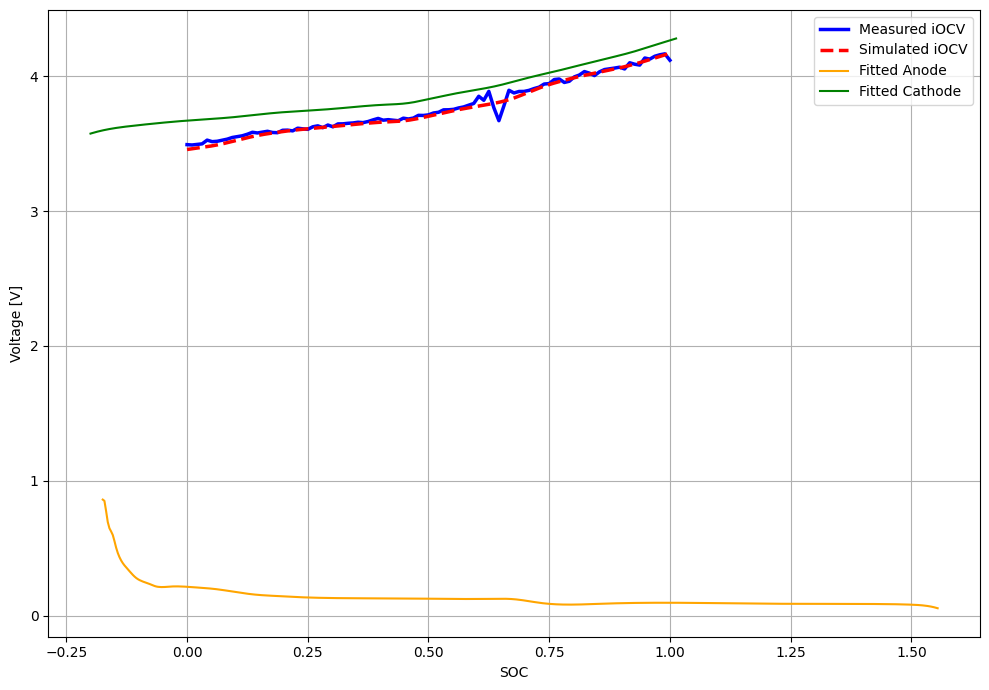

In [6]:
import pandas as pd
from pydpeet.process.analyze.extract.half_cell_fitting import plot_half_cell_match
best_anode_file   = best["Anode"].iloc[0]
best_cathode_file = best["Cathode"].iloc[0]
solution_array    = best["Solution_Array"].iloc[0]

anode_raw   = pd.read_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/src/pydpeet/res/fitting_data/halfCellAnodes/"+ best_anode_file)
cathode_raw = pd.read_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/src/pydpeet/res/fitting_data/halfCellCathodes/"+best_cathode_file)

df_for_plot = df_for_fit.copy()
soc = df_for_plot["SOC"]
df_for_plot["SOC"] = (soc - soc.min()) / (soc.max() - soc.min())

plot_half_cell_match(
    full_df=df_for_plot,
    anode_df=anode_raw,
    cathode_df=cathode_raw,
    solution_array=solution_array,
    filename="BestMatch_Real_lange_pause.png",
)

In [7]:
from pydpeet.process.analyze.extract.field_data_loader import (
    split_by_time_window,
)

chunks=split_by_time_window(df_field, window_days=30)

print(f"{len(chunks)} Fenster")
for i, c in enumerate(chunks):
    t0 = c["Test_Time[s]"].iloc[0] / 86400
    t1 = c["Test_Time[s]"].iloc[-1] / 86400
    print(f"  chunk {i}: rows={len(c):>8}, Tag {t0:.1f}–{t1:.1f}")

32 Fenster
  chunk 0: rows=  181605, Tag 0.0–30.0
  chunk 1: rows=  184930, Tag 30.0–60.0
  chunk 2: rows=  180042, Tag 61.0–90.0
  chunk 3: rows=  179132, Tag 90.0–120.0
  chunk 4: rows=  193790, Tag 120.0–150.0
  chunk 5: rows=  166814, Tag 150.0–180.0
  chunk 6: rows=  150907, Tag 180.0–210.0
  chunk 7: rows=  147378, Tag 210.0–239.9
  chunk 8: rows=  161858, Tag 240.2–270.0
  chunk 9: rows=  170260, Tag 270.2–300.0
  chunk 10: rows=  122938, Tag 300.3–330.0
  chunk 11: rows=  147848, Tag 330.0–360.0
  chunk 12: rows=  169335, Tag 360.3–390.0
  chunk 13: rows=  146210, Tag 390.3–419.9
  chunk 14: rows=  169515, Tag 420.2–449.9
  chunk 15: rows=  183274, Tag 450.3–480.0
  chunk 16: rows=  168958, Tag 480.0–510.0
  chunk 17: rows=  171908, Tag 510.0–538.0
  chunk 18: rows=    2626, Tag 569.0–569.8
  chunk 19: rows=   22862, Tag 570.3–574.0
  chunk 20: rows=   12053, Tag 628.0–630.0
  chunk 21: rows=  160683, Tag 630.0–659.0
  chunk 22: rows=    2132, Tag 689.0–689.9
  chunk 23: rows= 

 chunk  dSOC  dauer_h   Cap_Ah
     8 -0.31    24.02  2180.91
    10 -0.18   174.98  7241.84
    26 -0.42    11.83  1392.30
    29 -0.17   569.45 27632.25


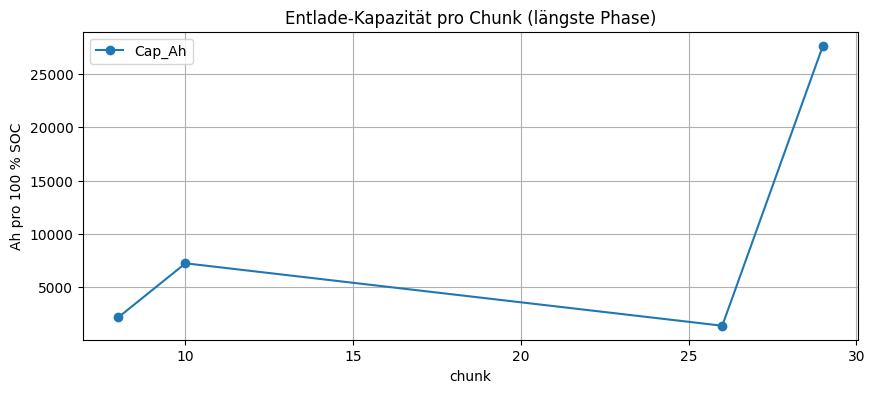

In [8]:
import pydpeet.process.analyze.extract.capa_new as capa
rows = []
CUR  = "Current[A]"      # ggf. anpassen (du hattest "Amper" genannt)
TIME = "Test_Time[s]"
for idx, chunk in enumerate(chunks):
    ph = capa.find_longest_discharge_phase(chunk, current_col=CUR, time_col=TIME)
    if len(ph) < 2:
        continue
    c = capa.capacity_full_soc_mAh(ph, current_col=CUR, time_col=TIME)
    if c == c:  # nicht NaN
        rows.append({"chunk": idx,
                     "dSOC": ph["SOC"].iloc[-1] - ph["SOC"].iloc[0],
                     "dauer_h": (ph[TIME].iloc[-1] - ph[TIME].iloc[0]) / 3600,
                     "Cap_Ah": c / 1000})
res = pd.DataFrame(rows)
print(res.round(2).to_string(index=False))

if not res.empty:
    res.plot(x="chunk", y="Cap_Ah", marker="o", grid=True, figsize=(10, 4),
             title="Entlade-Kapazität pro Chunk (längste Phase)")
    plt.ylabel("Ah pro 100 % SOC"); plt.show()


In [9]:
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

anchors_per_chunk: list = []  
for i, chunk in enumerate(chunks):
    pauses = extract_pauses(chunk, min_pause_duration_s=600)
    if not pauses:
        anchors_per_chunk.append(None) 
        print(f"chunk {i:>2}: keine Pausen ≥ 600 s")
        continue
    anchors = pauses_to_ocv_simple(pauses)
    anchors_per_chunk.append(anchors)
    print(f"chunk {i:>2}: {len(pauses):>4} Pausen → {len(anchors):>4} OCV-Endpunkte")


chunk  0:   46 Pausen →   46 OCV-Endpunkte
chunk  1:   17 Pausen →   17 OCV-Endpunkte
chunk  2:   27 Pausen →   27 OCV-Endpunkte
chunk  3:   25 Pausen →   25 OCV-Endpunkte
chunk  4:   39 Pausen →   39 OCV-Endpunkte
chunk  5:   39 Pausen →   39 OCV-Endpunkte
chunk  6:   36 Pausen →   36 OCV-Endpunkte
chunk  7:   32 Pausen →   32 OCV-Endpunkte
chunk  8:   40 Pausen →   40 OCV-Endpunkte
chunk  9:   42 Pausen →   42 OCV-Endpunkte
chunk 10:   25 Pausen →   25 OCV-Endpunkte
chunk 11:   38 Pausen →   38 OCV-Endpunkte
chunk 12:   34 Pausen →   34 OCV-Endpunkte
chunk 13:   45 Pausen →   45 OCV-Endpunkte
chunk 14:   42 Pausen →   42 OCV-Endpunkte
chunk 15:   52 Pausen →   52 OCV-Endpunkte
chunk 16:   48 Pausen →   48 OCV-Endpunkte
chunk 17:   23 Pausen →   23 OCV-Endpunkte
chunk 18:    5 Pausen →    5 OCV-Endpunkte
chunk 19:    4 Pausen →    4 OCV-Endpunkte
chunk 20:    4 Pausen →    4 OCV-Endpunkte
chunk 21:   40 Pausen →   40 OCV-Endpunkte
chunk 22:    3 Pausen →    3 OCV-Endpunkte
chunk 23:  

In [10]:
from pydpeet.process.analyze.extract.half_cell_fitting import get_best_half_cell_fit

MIN_POINTS = 20 

best_per_chunk: list = [] 
for i, anchors in enumerate(anchors_per_chunk):
    if anchors is None or len(anchors) < MIN_POINTS:
        best_per_chunk.append(None)
        print(f"chunk {i:>2}: nur {0 if anchors is None else len(anchors)} OCV-Punkte → übersprungen")
        continue

    df_for_fit = (
        anchors[["SOC", "U"]]
            .rename(columns={"U": "Voltage[V]"})
            .dropna()
            .sort_values("SOC")
            .drop_duplicates(subset="SOC")
            .reset_index(drop=True)
    )
    if len(df_for_fit) < MIN_POINTS:
        best_per_chunk.append(None)
        print(f"chunk {i:>2}: nach Bereinigung nur {len(df_for_fit)} Punkte → übersprungen")
        continue

    best = get_best_half_cell_fit(df_for_fit, full_cell_name=f"chunk_{i:02d}")
    best_per_chunk.append(best)
    print(f"chunk {i:>2}: {len(df_for_fit):>3} Punkte → fit OK")


chunk  0:  32 Punkte → fit OK
chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nach Bereinigung nur 19 Punkte → übersprungen
chunk  3: nach Bereinigung nur 15 Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk 10: nach Bereinigung nur 19 Punkte → übersprungen
chunk 11:  28 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 17: nach Bereinigung nur 17 Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 21:  24 Punkte → fit OK
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 23:  46 Punkte → fit OK
chunk 24:  36 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 26:  35 Punkte → fit OK
chunk 27:  32 Punkte → fi

   chunk   RMSE[mV]                            Anode  \
0     16   6.877879          Graphite, Ecker2015.csv   
1     28   7.556270             Graphite, Li2012.csv   
2      0   9.232025  Graphite-Silicon, Sturm2019.csv   
3     14  10.595983    Graphite, Schmalstieg2018.csv   
4     27  10.961329  Graphite-Silicon, Sturm2019.csv   

                     Cathode  Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  \
0  NMC622, Chaouachi2021.csv       0.137309       0.914509         0.263310   
1        NMC, Dufour2018.csv       0.300000       0.689233         0.414858   
2      NMC811, Sturm2019.csv       0.254935       0.677030         0.132855   
3        NMC622, Gao2018.csv       0.144197       0.664086         0.047835   
4        NMC, Liebig2019.csv       0.086481       0.836393         0.427835   

   Sol_Cathode_Max  
0         0.807370  
1         0.920866  
2         0.807112  
3         0.731387  
4         0.924983  

chunk 16  RMSE=6.88 mV  Anode=Graphite, Ecker2015.csv  Cathod

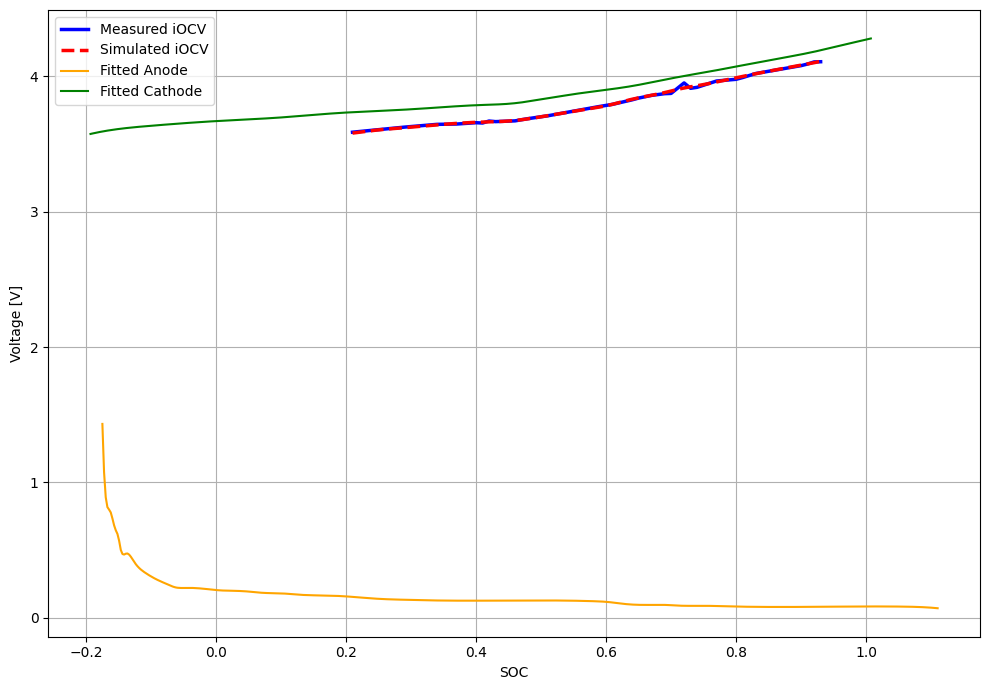


chunk 28  RMSE=7.56 mV  Anode=Graphite, Li2012.csv  Cathode=NMC, Dufour2018.csv


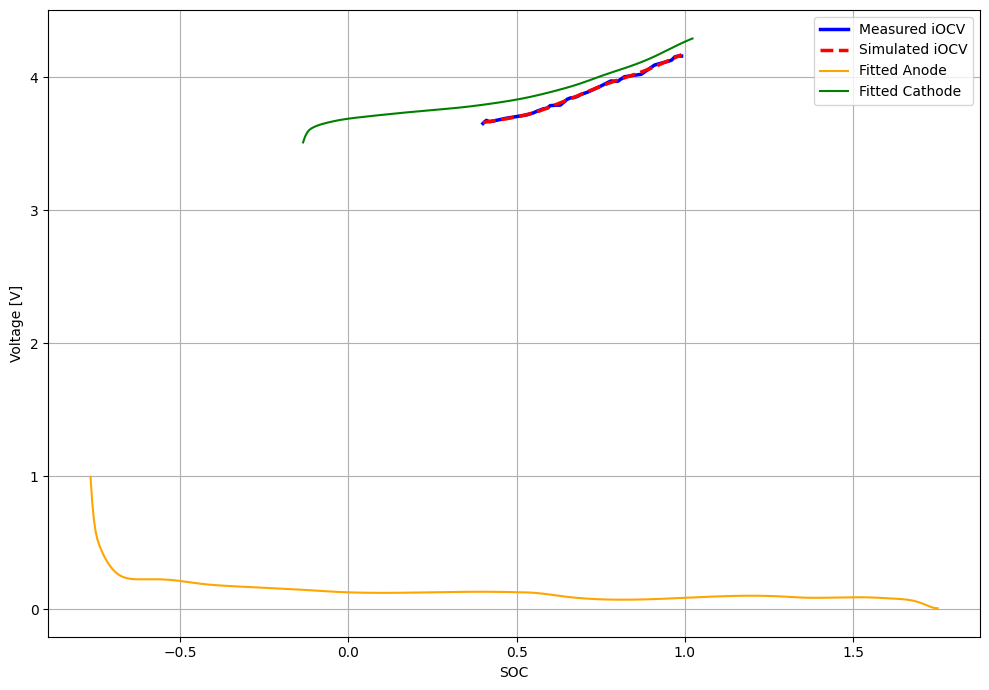


chunk 00  RMSE=9.23 mV  Anode=Graphite-Silicon, Sturm2019.csv  Cathode=NMC811, Sturm2019.csv


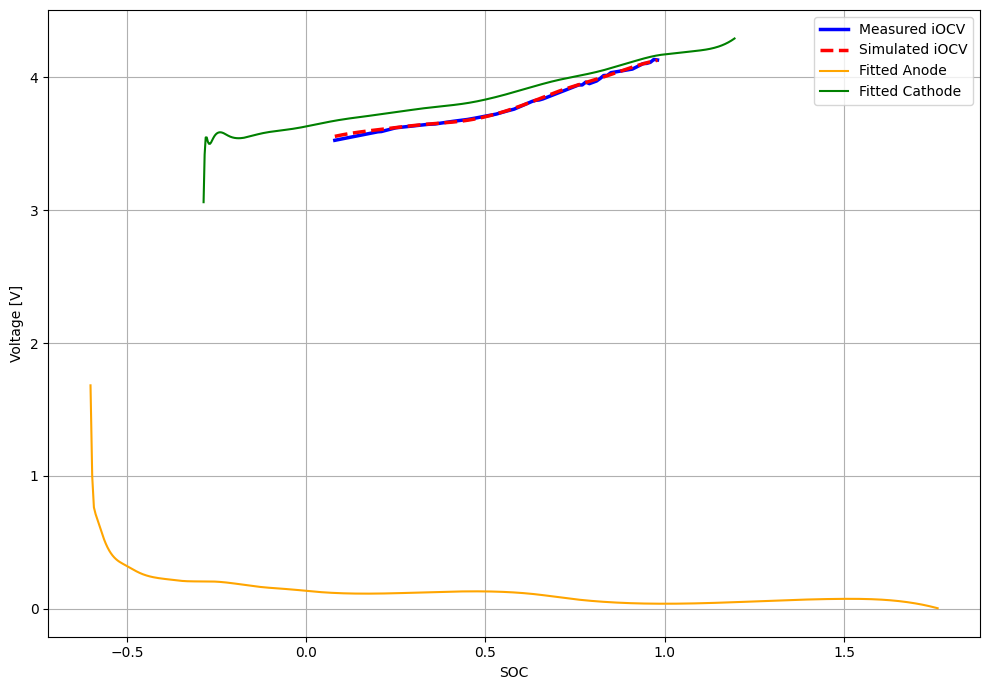


chunk 14  RMSE=10.60 mV  Anode=Graphite, Schmalstieg2018.csv  Cathode=NMC622, Gao2018.csv


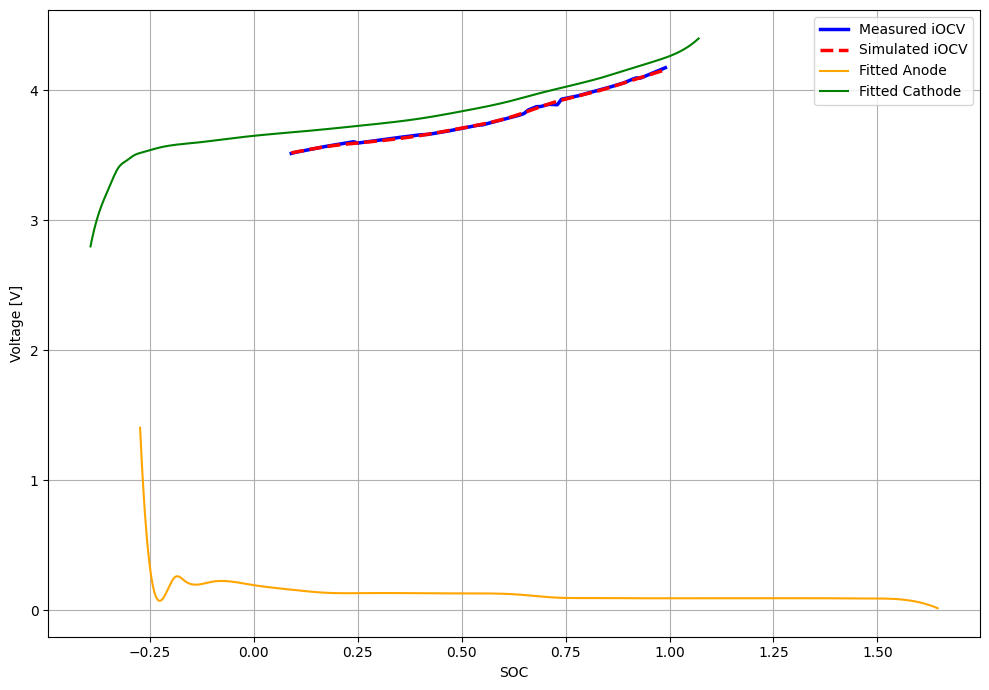


chunk 27  RMSE=10.96 mV  Anode=Graphite-Silicon, Sturm2019.csv  Cathode=NMC, Liebig2019.csv


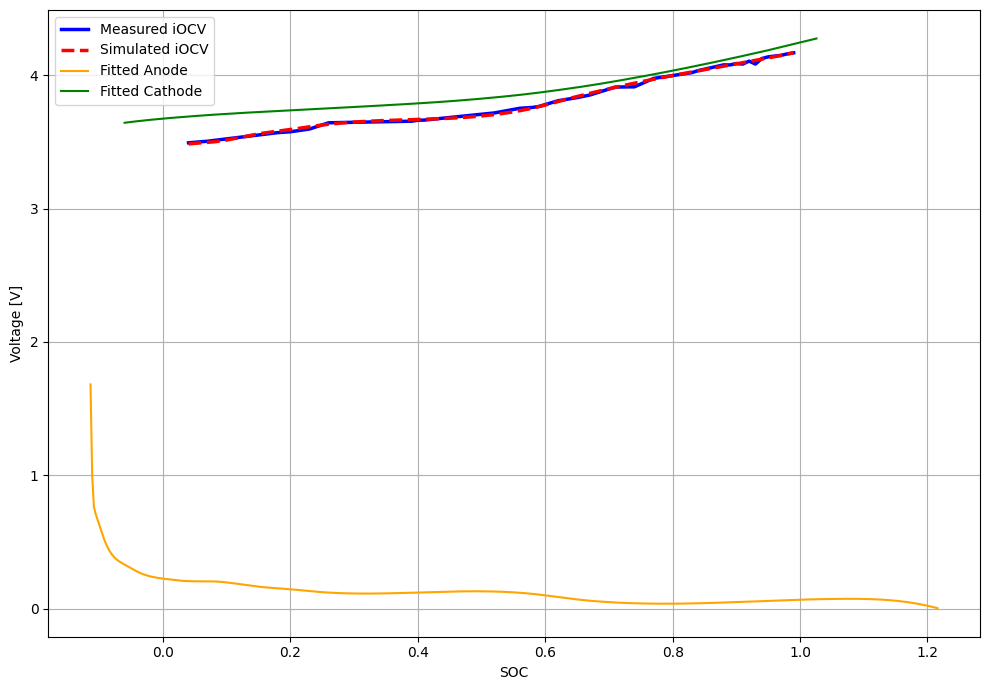

In [11]:
from pydpeet.process.analyze.extract.half_cell_fitting import (
    plot_half_cell_match,
    dir_anode,
    dir_cathode,
)

fits_overview = pd.concat(
    [b.assign(chunk=i) for i, b in enumerate(best_per_chunk) if b is not None and not b.empty],
    ignore_index=True,
)
top5 = fits_overview.sort_values("RMSE[mV]").head(5).reset_index(drop=True)
print(top5[["chunk", "RMSE[mV]", "Anode", "Cathode",
            "Sol_Anode_Min", "Sol_Anode_Max",
            "Sol_Cathode_Min", "Sol_Cathode_Max"]])

for _, row in top5.iterrows():
    chunk_idx = int(row["chunk"])

    df_for_fit = (
        anchors_per_chunk[chunk_idx][["SOC", "U"]]
            .rename(columns={"U": "Voltage[V]"})
            .dropna()
            .sort_values("SOC")
            .drop_duplicates(subset="SOC")
            .reset_index(drop=True)
    )

    anode_raw   = pd.read_csv(f"{dir_anode}/{row['Anode']}")
    cathode_raw = pd.read_csv(f"{dir_cathode}/{row['Cathode']}")

    print(f"\nchunk {chunk_idx:02d}  RMSE={row['RMSE[mV]']:.2f} mV  "
          f"Anode={row['Anode']}  Cathode={row['Cathode']}")
    plot_half_cell_match(
        full_df=df_for_fit,
        anode_df=anode_raw,
        cathode_df=cathode_raw,
        solution_array=row["Solution_Array"],
        filename=f"BestMatch_chunk{chunk_idx:02d}.png",
    )


In [12]:
from pydpeet.process.analyze.extract.half_cell_fitting import find_best_half_cell_match
MAX_RMSE_MV = 50
def _chunk_to_fit_df(anchors):
    return (anchors[["SOC", "U"]]
            .rename(columns={"U": "Voltage[V]"})
            .dropna()
            .sort_values("SOC")
            .drop_duplicates(subset="SOC")
            .reset_index(drop=True))


all_pair_fits = []
for i, anchors in enumerate(anchors_per_chunk):
    if anchors is None or len(anchors) < MIN_POINTS:
        continue
    df_for_fit = _chunk_to_fit_df(anchors)
    if len(df_for_fit) < MIN_POINTS:
        continue
    ranking = find_best_half_cell_match(df_for_fit, full_cell_name=f"chunk_{i:02d}")
    if ranking.empty:
        continue
    all_pair_fits.append(ranking.assign(chunk=i))

all_pair_fits = pd.concat(all_pair_fits, ignore_index=True)
chunk_best_rmse = all_pair_fits.groupby("chunk")["RMSE[mV]"].min()
good_chunks = chunk_best_rmse[chunk_best_rmse <= MAX_RMSE_MV].index
bad_chunks  = chunk_best_rmse[chunk_best_rmse >  MAX_RMSE_MV]

if len(bad_chunks):
    print(f"Verworfen (bester Fit > {MAX_RMSE_MV} mV):")
    for c, r in bad_chunks.items():
        print(f"  chunk {c:>2}: bester RMSE {r:.1f} mV")

all_pair_fits = all_pair_fits[all_pair_fits["chunk"].isin(good_chunks)].reset_index(drop=True)
n_chunks_fitted = all_pair_fits["chunk"].nunique()
print(f"{len(good_chunks)} Chunks behalten, {len(bad_chunks)} verworfen")
print(f"{n_chunks_fitted} Chunks gefittet, "
      f"{all_pair_fits.groupby(['Anode','Cathode']).ngroups} Halbzellpaare bewertet")


KeyboardInterrupt: 

In [ ]:

pair_consensus = (
    all_pair_fits
        .groupby(["Anode", "Cathode"])
        .agg(n_chunks=("chunk", "nunique"),
             median_rmse=("RMSE[mV]", "median"),
             mean_rmse=("RMSE[mV]", "mean"),
             max_rmse=("RMSE[mV]", "max"))
        .reset_index()
)

pair_consensus = pair_consensus[pair_consensus["n_chunks"] == n_chunks_fitted]

winners = (all_pair_fits.loc[all_pair_fits.groupby("chunk")["RMSE[mV]"].idxmin(),
                             ["Anode", "Cathode"]]
           .value_counts().rename("wins").reset_index())
pair_consensus = (pair_consensus.merge(winners, on=["Anode", "Cathode"], how="left"))
pair_consensus["wins"] = pair_consensus["wins"].fillna(0).astype(int)

pair_consensus = pair_consensus.sort_values("median_rmse").reset_index(drop=True)

print("Top-10 Halbzellpaare nach Median-RMSE über alle Chunks:")
print(pair_consensus.head(10).to_string(index=False))

fixed_anode   = pair_consensus.iloc[0]["Anode"]
fixed_cathode = pair_consensus.iloc[0]["Cathode"]
print(f"\nGewähltes Konsens-Paar: {fixed_anode}  +  {fixed_cathode}")


Top-10 Halbzellpaare nach Median-RMSE über alle Chunks:
                         Anode                   Cathode  n_chunks  median_rmse  mean_rmse  max_rmse  wins
   Graphite, Chaouachi2021.csv NMC622, Chaouachi2021.csv        16    15.478469  16.547587 36.268997     4
       Graphite, Ecker2015.csv NMC622, Chaouachi2021.csv        16    15.847611  16.625033 37.495828     2
 Graphite, Schmalstieg2018.csv NMC622, Chaouachi2021.csv        16    15.985478  16.718997 37.119887     0
Graphite-Silicon, Chen2020.csv NMC622, Chaouachi2021.csv        16    16.033291  16.705771 36.834798     0
        Graphite, Hust2019.csv       NMC622, Gao2018.csv        16    16.055538  17.458557 38.176242     0
      Graphite, Liebig2019.csv NMC622, Chaouachi2021.csv        16    16.121182  16.972527 37.610215     0
          Graphite, Li2012.csv        NMC111, Wu2012.csv        16    16.142000  16.979183 32.620332     1
      Graphite, Liebig2019.csv        NMC111, Wu2012.csv        16    16.362922  17.1643

In [ ]:
from pydpeet.process.analyze.extract.half_cell_fitting import fit_half_cells, dir_anode, dir_cathode

anode_fix   = pd.read_csv(f"{dir_anode}/{fixed_anode}")
cathode_fix = pd.read_csv(f"{dir_cathode}/{fixed_cathode}")

rows = []
for i, anchors in enumerate(anchors_per_chunk):
    if anchors is None or len(anchors) < MIN_POINTS:
        continue
    df_for_fit = _chunk_to_fit_df(anchors)
    if len(df_for_fit) < MIN_POINTS:
        continue
    res = fit_half_cells(
        full_df=df_for_fit,
        anode_df=anode_fix,
        cathode_df=cathode_fix,
        full_cell_name=f"chunk_{i:02d}",
        anode_name=fixed_anode,
        cathode_name=fixed_cathode,
    )
    if res.empty or res["RMSE[mV]"].iloc[0] > MAX_RMSE_MV:
        print(f"chunk {i:>2}: Fit > {MAX_RMSE_MV} mV → nicht im Trend")
        continue
    rows.append(res.assign(
        chunk=i,
        t_start_day=chunks[i]["Test_Time[s]"].iloc[0] / 86400,
        t_end_day=chunks[i]["Test_Time[s]"].iloc[-1] / 86400,
    ))

stoich_trend = pd.concat(rows, ignore_index=True).sort_values("chunk").reset_index(drop=True)
print(stoich_trend[["chunk", "t_start_day", "RMSE[mV]",
                    "Sol_Anode_Min", "Sol_Anode_Max",
                    "Sol_Cathode_Min", "Sol_Cathode_Max"]].to_string(index=False))


chunk  4: Fit > 50 mV → nicht im Trend
chunk  7: Fit > 50 mV → nicht im Trend
chunk  9: Fit > 50 mV → nicht im Trend
chunk 13: Fit > 50 mV → nicht im Trend
chunk 30: Fit > 50 mV → nicht im Trend
 chunk  t_start_day  RMSE[mV]  Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max
     0     0.000000  9.529224       0.296383       0.641942         0.270719         0.798507
     5   150.000104 17.001856       0.061657       0.826486         0.276129         0.806534
     6   180.000069 22.175514       0.254989       0.600000         0.285663         0.830637
     8   240.234688 24.689332       0.119508       0.751903         0.277129         0.805411
    11   330.000035 17.305026       0.052101       0.886769         0.259364         0.802196
    12   360.259167 17.326741       0.039296       0.849910         0.277893         0.792102
    14   420.227303 12.195586       0.111502       0.747402         0.263882         0.822655
    15   450.272523 14.062729       0.020603       0.

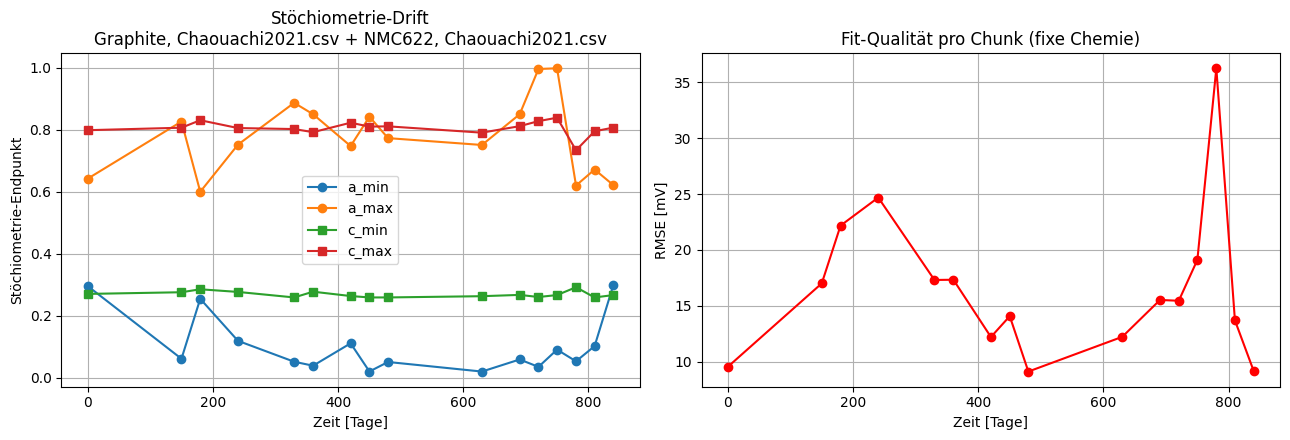

In [ ]:
import matplotlib.pyplot as plt

x = stoich_trend["t_start_day"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(x, stoich_trend["Sol_Anode_Min"],   "o-", label="a_min")
ax[0].plot(x, stoich_trend["Sol_Anode_Max"],   "o-", label="a_max")
ax[0].plot(x, stoich_trend["Sol_Cathode_Min"], "s-", label="c_min")
ax[0].plot(x, stoich_trend["Sol_Cathode_Max"], "s-", label="c_max")
ax[0].set_xlabel("Zeit [Tage]"); ax[0].set_ylabel("Stöchiometrie-Endpunkt")
ax[0].set_title(f"Stöchiometrie-Drift\n{fixed_anode} + {fixed_cathode}")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(x, stoich_trend["RMSE[mV]"], "o-", color="red")
ax[1].set_xlabel("Zeit [Tage]"); ax[1].set_ylabel("RMSE [mV]")
ax[1].set_title("Fit-Qualität pro Chunk (fixe Chemie)")
ax[1].grid(True)
plt.tight_layout(); plt.show()


   RMSE[mV]                  Anode               Cathode  Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max
6346.026318 Graphite, Hust2019.csv LMO, Albertus2009.csv            0.3       0.998369         0.350752              0.6


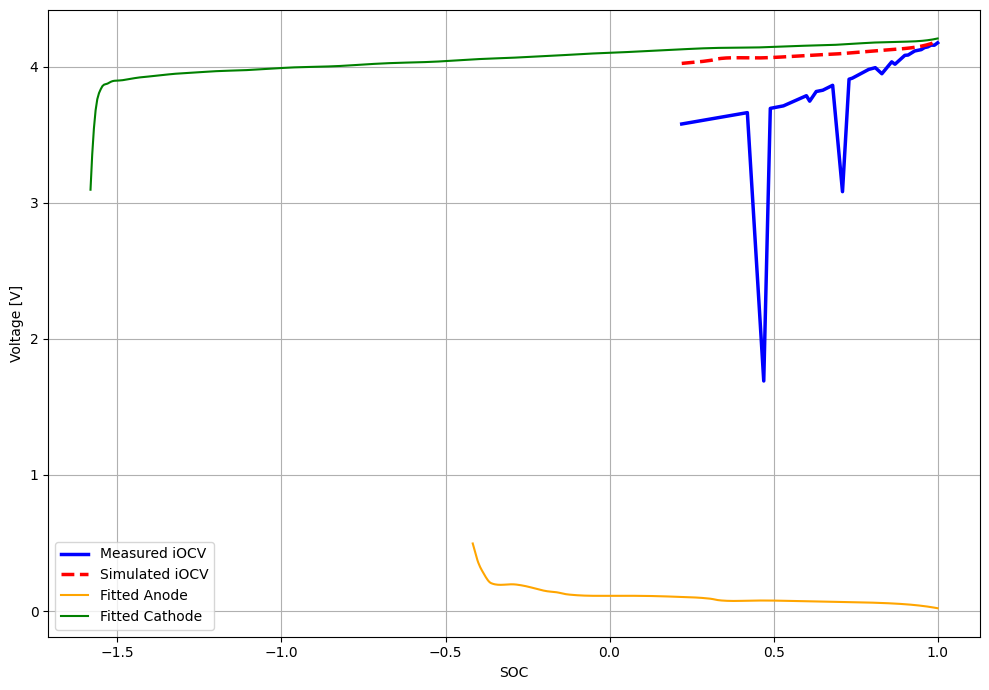

In [ ]:
import pandas as pd
from pydpeet.process.analyze.extract.half_cell_fitting import (
    get_best_half_cell_fit, plot_half_cell_match, dir_anode, dir_cathode,
)

CHUNK = 30

df_for_fit = (
    anchors_per_chunk[CHUNK][["SOC", "U"]]
        .rename(columns={"U": "Voltage[V]"})
        .dropna()
        .sort_values("SOC")
        .drop_duplicates(subset="SOC")
        .reset_index(drop=True)
)

best = get_best_half_cell_fit(df_for_fit, full_cell_name=f"chunk_{CHUNK:02d}")
print(best[["RMSE[mV]", "Anode", "Cathode",
            "Sol_Anode_Min", "Sol_Anode_Max",
            "Sol_Cathode_Min", "Sol_Cathode_Max"]].to_string(index=False))

anode_raw   = pd.read_csv(f"{dir_anode}/{best['Anode'].iloc[0]}")
cathode_raw = pd.read_csv(f"{dir_cathode}/{best['Cathode'].iloc[0]}")

plot_half_cell_match(
    full_df=df_for_fit,                  
    anode_df=anode_raw,
    cathode_df=cathode_raw,
    solution_array=best["Solution_Array"].iloc[0],
    filename=f"BestMatch_chunk{CHUNK:02d}.png",
)


In [ ]:
from pydpeet.process.analyze.extract.fit_real_data import fit_real_data

result = fit_real_data(df_field,max_rmse_mv=30,sort_by="mean")         
print(result.head(10).to_string(index=False))


chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nur 19 OCV-Punkte → übersprungen
chunk  3: nur 15 OCV-Punkte → übersprungen
chunk 10: nur 19 OCV-Punkte → übersprungen
chunk 17: nur 17 OCV-Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 29: nur 10 OCV-Punkte → übersprungen
chunk 31: nur 13 OCV-Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk  0:  32 Punkte → fit OK
chunk 11:  28 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 30:  27 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 23:  46 Punkte → fit OK
chunk 24:  36 Punkte → fit OK
chunk 27:  32 Punkte 

In [ ]:
import numpy as np
import pandas as pd
def estimate_chunk_capacity_mAh(df: pd.DataFrame, min_soc_distance: float = 0.5) -> float:
    """
    Schätzt die Vollzellen-Kapazität (mAh) eines Felddaten-Chunks per
    Coulomb-Counting gegen SOC:

        C = ∫|I| dt  /  Σ|ΔSOC|        (in Ah pro 100% SOC)

    Liefert NaN, wenn der Chunk zu wenig SOC-Bewegung enthält
    (min_soc_distance, default 0.5 = mind. einer halben Vollzyklus-Strecke).
    """
    d = df.dropna(subset=["SOC", "Current[A]", "Test_Time[s]"]) \
          .sort_values("Test_Time[s]") \
          .reset_index(drop=True)
    if len(d) < 2:
        return float("nan")

    soc = d["SOC"].to_numpy(dtype=float)
    t   = d["Test_Time[s]"].to_numpy(dtype=float)
    i   = d["Current[A]"].to_numpy(dtype=float)

    soc_distance = float(np.abs(np.diff(soc)).sum())
    if soc_distance < min_soc_distance:
        return float("nan")

    dt = np.diff(t)
    i_avg = (np.abs(i[1:]) + np.abs(i[:-1])) / 2.0
    ah_throughput = float((i_avg * dt).sum() / 3600.0)

    return ah_throughput / soc_distance * 1000.0   # mAh pro 100% SOC


# Anwendung auf df_field als Ganzes
cap_field_mAh = estimate_chunk_capacity_mAh(df_field)
print(f"df_field gesamt: ~{cap_field_mAh:,.0f} mAh ({cap_field_mAh/1000:.1f} Ah)")

# Anwendung pro 30-Tage-Chunk
cap_per_chunk_mAh = [estimate_chunk_capacity_mAh(c) for c in chunks]
cap_df = pd.DataFrame({
    "chunk":      range(len(chunks)),
    "n_samples":  [len(c) for c in chunks],
    "Cap_mAh":    cap_per_chunk_mAh,
    "Cap_Ah":     [c/1000 if c == c else float("nan") for c in cap_per_chunk_mAh],
})
print(cap_df.to_string(index=False))

df_field gesamt: ~184,058 mAh (184.1 Ah)
 chunk  n_samples       Cap_mAh     Cap_Ah
     0     181605 148680.524852 148.680525
     1     184930 147871.488734 147.871489
     2     180042 147492.935674 147.492936
     3     179132 156223.395054 156.223395
     4     193790 151400.359153 151.400359
     5     166814 178702.645877 178.702646
     6     150907 151599.957273 151.599957
     7     147378 151185.915304 151.185915
     8     161858 153472.619804 153.472620
     9     170260 148364.460189 148.364460
    10     122938 170714.302167 170.714302
    11     147848 193333.559345 193.333559
    12     169335 152485.316283 152.485316
    13     146210 148739.710208 148.739710
    14     169515 145068.321449 145.068321
    15     183274 146397.931396 146.397931
    16     168958 125214.213984 125.214214
    17     171908 144519.909953 144.519910
    18       2626 147992.935982 147.992936
    19      22862 151361.499566 151.361500
    20      12053 144992.551914 144.992552
    21     16

21 verwertbare Chunks: [0, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 21, 23, 24, 25, 26, 27, 28, 30]

Rolling LLI/LAM (vs. vorheriger gültiger Chunk):
    ref_chunk  chunk  Full_Cell_Cap_mAh  SOH_pct  LLI_pct  LAM_Anode_pct  \
0           0      4          151400.36   101.83    -1.83          43.08   
1           4      5          178702.65   118.03   -18.03         -29.82   
2           5      6          151599.96    84.83    15.17           1.56   
3           6      7          151185.92    99.73     0.27         -13.68   
4           7      8          153472.62   101.51    -1.51          19.17   
5           8      9          148364.46    96.67     3.33          31.52   
6           9     11          193333.56   130.31   -30.31         -43.67   
7          11     12          152485.32    78.87    21.13          21.68   
8          12     13          148739.71    97.54     2.46         -69.93   
9          13     14          145068.32    97.53     2.47           9.49   
10         14

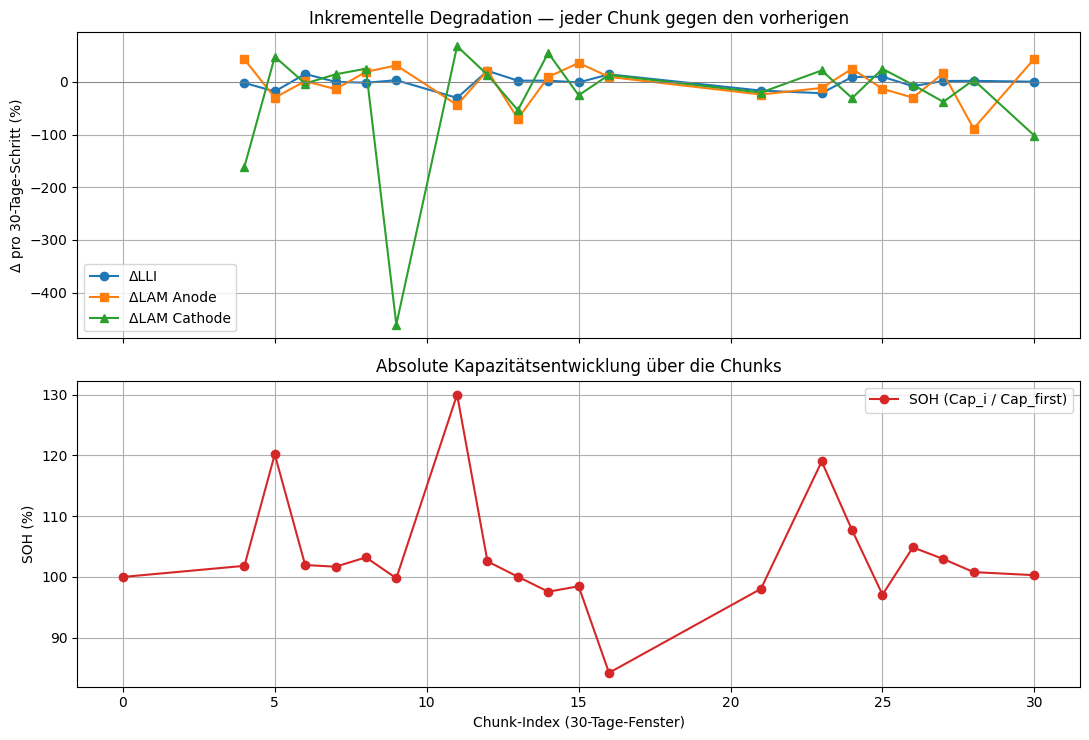

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pydpeet.process.analyze.extract.lithium_amount import calculate_electrode_quantities
from pydpeet.process.analyze.extract.lli_lam import calculate_lli_lam

# 1) Nur Chunks behalten, die in den vorherigen Schritten überlebt haben:
#    - best_per_chunk[i] vorhanden + nicht leer  (Half-Cell-Fit OK)
#    - SOC-Kapazität finit                       (genug SOC-Bewegung im Fenster)
quantities_per_chunk: dict[int, pd.DataFrame] = {}
cap_per_chunk_mAh: dict[int, float] = {}
for i, fit in enumerate(best_per_chunk):
    if fit is None or fit.empty:
        continue
    cap = estimate_chunk_capacity_mAh(chunks[i])
    if not np.isfinite(cap):
        continue
    quantities_per_chunk[i] = calculate_electrode_quantities(fit, full_cap_mAh=cap)
    cap_per_chunk_mAh[i] = cap

valid_ids = sorted(quantities_per_chunk.keys())
print(f"{len(valid_ids)} verwertbare Chunks: {valid_ids}")

# 2) Rolling-Vergleich: jeder Chunk vs. den jeweils vorhergehenden gültigen Chunk
rolling = []
for ref_id, cur_id in zip(valid_ids[:-1], valid_ids[1:]):
    res = calculate_lli_lam(
        ref_quantities  = quantities_per_chunk[ref_id],
        aged_quantities = quantities_per_chunk[cur_id],
    )
    rolling.append(res.assign(ref_chunk=ref_id, chunk=cur_id))

rolling_df = pd.concat(rolling, ignore_index=True)
print("\nRolling LLI/LAM (vs. vorheriger gültiger Chunk):")
print(rolling_df[["ref_chunk", "chunk", "Full_Cell_Cap_mAh",
                  "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].round(2))

# 3) Plot
x = rolling_df["chunk"].to_numpy()

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

# oben: inkrementelle Δ pro Schritt (genau das, was der Rolling-Vergleich liefert)
ax_top.plot(x, rolling_df["LLI_pct"],         "o-", label="ΔLLI",         color="tab:blue")
ax_top.plot(x, rolling_df["LAM_Anode_pct"],   "s-", label="ΔLAM Anode",   color="tab:orange")
ax_top.plot(x, rolling_df["LAM_Cathode_pct"], "^-", label="ΔLAM Cathode", color="tab:green")
ax_top.axhline(0, color="0.5", lw=0.6)
ax_top.set_ylabel("Δ pro 30-Tage-Schritt (%)")
ax_top.set_title("Inkrementelle Degradation — jeder Chunk gegen den vorherigen")
ax_top.grid(True); ax_top.legend()

# unten: SOH (Kapazität jedes Chunks normiert auf den ersten gültigen Chunk)
cap_first = cap_per_chunk_mAh[valid_ids[0]]
x_all = np.array(valid_ids)
soh_all = np.array([cap_per_chunk_mAh[i] / cap_first * 100 for i in valid_ids])
ax_bot.plot(x_all, soh_all, "o-", color="tab:red", label="SOH (Cap_i / Cap_first)")
ax_bot.set_xlabel("Chunk-Index (30-Tage-Fenster)")
ax_bot.set_ylabel("SOH (%)")
ax_bot.set_title("Absolute Kapazitätsentwicklung über die Chunks")
ax_bot.grid(True); ax_bot.legend()

plt.tight_layout()
plt.show()


In [ ]:
from pydpeet.process.analyze.extract.fit_real_data import fit_real_data
from pydpeet.process.analyze.extract.half_cell_fitting import (
    fit_half_cells, dir_anode, dir_cathode,
)
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

MAX_RMSE_MV = 50.0
MIN_POINTS  = 20

# 1) Konsens-Elektroden-Paar über alle Chunks bestimmen
consensus = fit_real_data(
    df_field,
    max_rmse_mv=MAX_RMSE_MV,
    min_points=MIN_POINTS,
    min_pause_duration_s=600,
)
top = consensus.iloc[0]
anode_file, cathode_file = top["Anode"], top["Cathode"]
print(f"Konsens: {anode_file}  +  {cathode_file}")
print(f"  median RMSE = {top['median_rmse']:.1f} mV  über {top['n_chunks']} Chunks")

anode_df   = pd.read_csv(f"{dir_anode}/{anode_file}")
cathode_df = pd.read_csv(f"{dir_cathode}/{cathode_file}")

# 2) Pro Chunk: refit gegen GENAU dieses Paar, RMSE-Gate + SOC-Kapazität
quantities_per_chunk: dict[int, pd.DataFrame] = {}
cap_per_chunk_mAh: dict[int, float] = {}
for i, chunk in enumerate(chunks):
    pauses = extract_pauses(chunk, min_pause_duration_s=600)
    if not pauses:
        continue
    anchors = pauses_to_ocv_simple(pauses)
    df_for_fit = (
        anchors[["SOC", "U"]].rename(columns={"U": "Voltage[V]"})
        .dropna().sort_values("SOC").drop_duplicates("SOC").reset_index(drop=True)
    )
    if len(df_for_fit) < MIN_POINTS:
        continue

    fit = fit_half_cells(
        df_for_fit, anode_df, cathode_df,
        anode_name=anode_file, cathode_name=cathode_file,
        full_cell_name=f"chunk_{i:02d}",
    )
    if fit.empty or float(fit["RMSE[mV]"].iloc[0]) > MAX_RMSE_MV:
        continue

    cap = estimate_chunk_capacity_mAh(chunk)
    if not np.isfinite(cap):
        continue

    quantities_per_chunk[i] = calculate_electrode_quantities(fit, full_cap_mAh=cap)
    cap_per_chunk_mAh[i] = cap

valid_ids = sorted(quantities_per_chunk.keys())
print(f"\n{len(valid_ids)} verwertbare Chunks nach Refit + RMSE-Filter: {valid_ids}")
# Rest des Rolling-LLI/LAM-Codes unverändert


chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nur 19 OCV-Punkte → übersprungen
chunk  3: nur 15 OCV-Punkte → übersprungen
chunk 10: nur 19 OCV-Punkte → übersprungen
chunk 17: nur 17 OCV-Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 29: nur 10 OCV-Punkte → übersprungen
chunk 31: nur 13 OCV-Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk 11:  28 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk  0:  32 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 30:  27 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 27:  32 Punkte → fit OK
chunk 21:  24 Punkte → fit OK
chunk 23:  46 Punkte 

Rolling LLI/LAM (vs. vorheriger gültiger Chunk):
    ref_chunk  chunk  Full_Cell_Cap_mAh  SOH_pct  LLI_pct  LAM_Anode_pct  \
0           0      5          178702.65   120.19   -20.19          45.70   
1           5      6          151599.96    84.83    15.17         -88.06   
2           6      8          153472.62   101.24    -1.24          44.77   
3           8     11          193333.56   125.97   -25.97           4.56   
4          11     12          152485.32    78.87    21.13          18.79   
5          12     14          145068.32    95.14     4.86         -21.27   
6          14     15          146397.93   100.92    -0.92          21.87   
7          15     16          125214.21    85.53    14.47           2.65   
8          16     21          145777.96   116.42   -16.42         -15.03   
9          21     23          176945.83   121.38   -21.38         -12.16   
10         23     24          160116.65    90.49     9.51          25.51   
11         24     25          144339.41

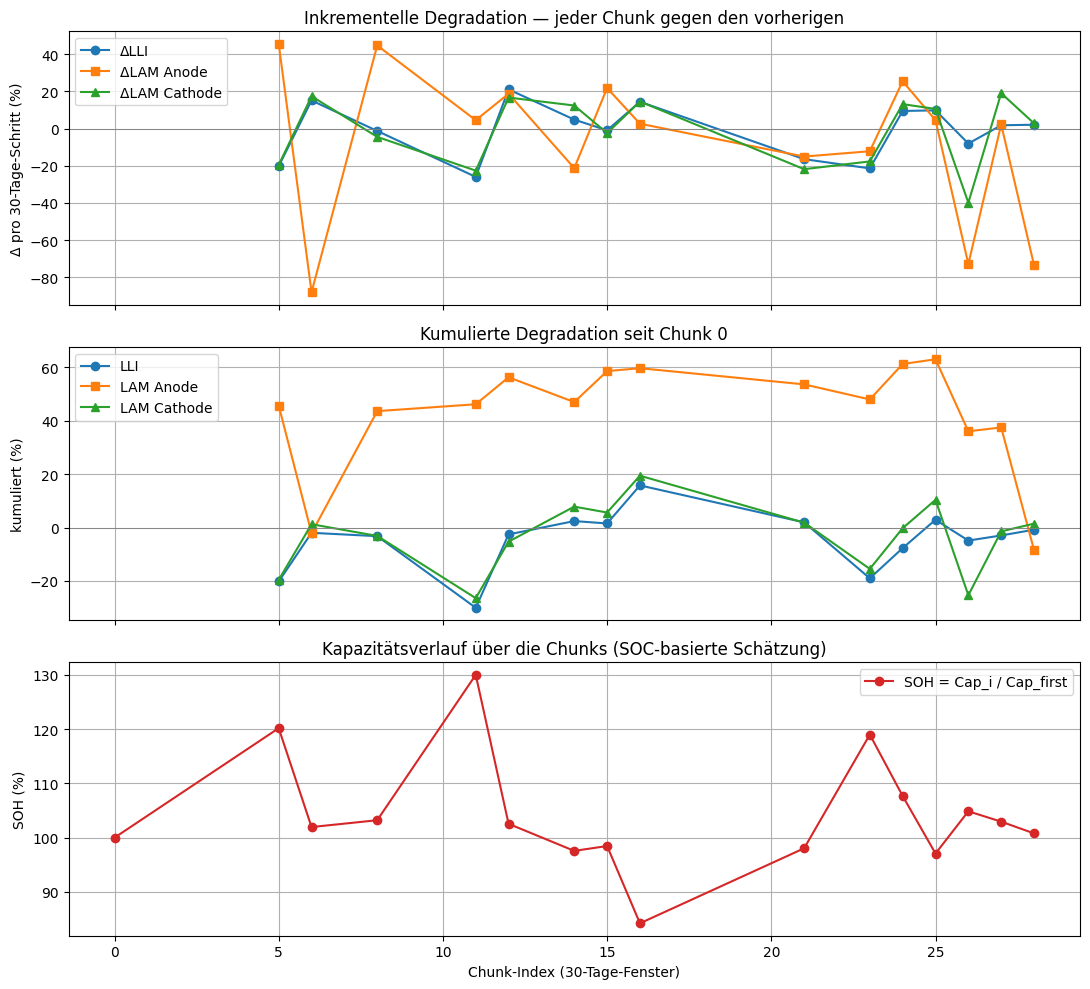

In [ ]:
from pydpeet.process.analyze.extract.lli_lam import calculate_lli_lam
import matplotlib.pyplot as plt

# 1) Rolling-Vergleich: jeder Chunk gegen den jeweils vorhergehenden gültigen
rolling_rows = []
for ref_id, cur_id in zip(valid_ids[:-1], valid_ids[1:]):
    res = calculate_lli_lam(
        ref_quantities  = quantities_per_chunk[ref_id],
        aged_quantities = quantities_per_chunk[cur_id],
    )
    rolling_rows.append(res.assign(ref_chunk=ref_id, chunk=cur_id))
rolling_df = pd.concat(rolling_rows, ignore_index=True)

# 2) Kumulativer Vergleich: jeder Chunk gegen den ersten gültigen Chunk
ref0 = valid_ids[0]
cum_rows = []
for cur_id in valid_ids[1:]:
    res = calculate_lli_lam(
        ref_quantities  = quantities_per_chunk[ref0],
        aged_quantities = quantities_per_chunk[cur_id],
    )
    cum_rows.append(res.assign(ref_chunk=ref0, chunk=cur_id))
cum_df = pd.concat(cum_rows, ignore_index=True)

print("Rolling LLI/LAM (vs. vorheriger gültiger Chunk):")
print(rolling_df[["ref_chunk", "chunk", "Full_Cell_Cap_mAh",
                  "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].round(2))

print(f"\nKumulativ (vs. Chunk {ref0}):")
print(cum_df[["chunk", "Full_Cell_Cap_mAh",
              "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].round(2))

# 3) Plot
fig, (ax_roll, ax_cum, ax_soh) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

# 3a) Rolling — inkrementelle Δ pro 30-Tage-Schritt
x_roll = rolling_df["chunk"].to_numpy()
ax_roll.plot(x_roll, rolling_df["LLI_pct"],         "o-", label="ΔLLI",         color="tab:blue")
ax_roll.plot(x_roll, rolling_df["LAM_Anode_pct"],   "s-", label="ΔLAM Anode",   color="tab:orange")
ax_roll.plot(x_roll, rolling_df["LAM_Cathode_pct"], "^-", label="ΔLAM Cathode", color="tab:green")
ax_roll.axhline(0, color="0.5", lw=0.6)
ax_roll.set_ylabel("Δ pro 30-Tage-Schritt (%)")
ax_roll.set_title("Inkrementelle Degradation — jeder Chunk gegen den vorherigen")
ax_roll.grid(True); ax_roll.legend()

# 3b) Kumulativ — alles gegen den ersten gültigen Chunk
x_cum = cum_df["chunk"].to_numpy()
ax_cum.plot(x_cum, cum_df["LLI_pct"],         "o-", label="LLI",         color="tab:blue")
ax_cum.plot(x_cum, cum_df["LAM_Anode_pct"],   "s-", label="LAM Anode",   color="tab:orange")
ax_cum.plot(x_cum, cum_df["LAM_Cathode_pct"], "^-", label="LAM Cathode", color="tab:green")
ax_cum.axhline(0, color="0.5", lw=0.6)
ax_cum.set_ylabel("kumuliert (%)")
ax_cum.set_title(f"Kumulierte Degradation seit Chunk {ref0}")
ax_cum.grid(True); ax_cum.legend()

# 3c) SOH-Trajektorie (absolute Kapazität, normiert auf den ersten gültigen Chunk)
cap_first = cap_per_chunk_mAh[ref0]
x_all = np.array(valid_ids)
soh_all = np.array([cap_per_chunk_mAh[i] / cap_first * 100 for i in valid_ids])
ax_soh.plot(x_all, soh_all, "o-", color="tab:red", label="SOH = Cap_i / Cap_first")
ax_soh.set_xlabel("Chunk-Index (30-Tage-Fenster)")
ax_soh.set_ylabel("SOH (%)")
ax_soh.set_title("Kapazitätsverlauf über die Chunks (SOC-basierte Schätzung)")
ax_soh.grid(True); ax_soh.legend()

plt.tight_layout()
plt.show()


In [ ]:
def estimate_chunk_capacity_robust_mAh(
    df: pd.DataFrame,
    *,
    min_segment_dsoc: float = 0.20,   # nur Segmente mit ≥ 20 % SOC-Hub
    min_current_a:    float = 1.0,    # Standby (|I| < 1 A) raus
    aggregator: str = "median",       # robust gegen Outlier-Segmente
) -> float:
    """
    Findet kontinuierliche Lade- oder Entlade-Segmente mit |ΔSOC| ≥ min_segment_dsoc
    bei aktivem Strom (|I| ≥ min_current_a). Pro Segment:
        C_seg = ∫|I| dt / |ΔSOC|     (in Ah pro 100 % SOC)
    und aggregiert über alle Segmente (Median per Default).
    """
    d = (df.dropna(subset=["SOC", "Current[A]", "Test_Time[s]"])
           .sort_values("Test_Time[s]")
           .reset_index(drop=True))
    if len(d) < 2:
        return float("nan")

    soc = d["SOC"].to_numpy(float)
    t   = d["Test_Time[s]"].to_numpy(float)
    i   = d["Current[A]"].to_numpy(float)

    # state: +1 = aktiv ladend, -1 = aktiv entladend, 0 = Standby / Sprung
    sign = np.where(i > 0, 1, np.where(i < 0, -1, 0))
    state = sign * (np.abs(i) >= min_current_a).astype(int)

    # Segmente = zusammenhängende Runs gleichen states
    changes = np.flatnonzero(np.diff(state)) + 1
    starts  = np.concatenate([[0], changes])
    ends    = np.concatenate([changes, [len(state)]])

    cap_estimates = []
    for s, e in zip(starts, ends):
        if state[s] == 0 or (e - s) < 2:
            continue
        d_soc = soc[e - 1] - soc[s]
        if abs(d_soc) < min_segment_dsoc:
            continue
        ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
        cap_estimates.append(ah / abs(d_soc) * 1000.0)   # mAh pro 100 % SOC

    if not cap_estimates:
        return float("nan")
    if aggregator == "median":
        return float(np.median(cap_estimates))
    return float(np.mean(cap_estimates))
# Anwendung auf df_field als Ganzes
cap_field_mAh = estimate_chunk_capacity_robust_mAh(df_field)
print(f"df_field gesamt: ~{cap_field_mAh:,.0f} mAh ({cap_field_mAh/1000:.1f} Ah)")

# Anwendung pro 30-Tage-Chunk
cap_per_chunk_mAh = [estimate_chunk_capacity_robust_mAh(c) for c in chunks]
cap_df = pd.DataFrame({
    "chunk":      range(len(chunks)),
    "n_samples":  [len(c) for c in chunks],
    "Cap_mAh":    cap_per_chunk_mAh,
    "Cap_Ah":     [c/1000 if c == c else float("nan") for c in cap_per_chunk_mAh],
})
print(cap_df.to_string(index=False))

/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0


df_field gesamt: ~121,822 mAh (121.8 Ah)


/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions

 chunk  n_samples       Cap_mAh     Cap_Ah
     0     181605 123410.185185 123.410185
     1     184930 124695.940171 124.695940
     2     180042 124262.948029 124.262948
     3     179132 121429.259259 121.429259
     4     193790 123367.487374 123.367487
     5     166814 120926.070290 120.926070
     6     150907 121260.734215 121.260734
     7     147378 121969.375857 121.969376
     8     161858 121140.053763 121.140054
     9     170260 119350.249288 119.350249
    10     122938 120856.052812 120.856053
    11     147848 121550.132275 121.550132
    12     169335 124296.350129 124.296350
    13     146210 124152.989130 124.152989
    14     169515 120848.713992 120.848714
    15     183274 120455.629630 120.455630
    16     168958 118775.555556 118.775556
    17     171908 117444.328704 117.444329
    18       2626 109467.663399 109.467663
    19      22862 113507.105870 113.507106
    20      12053 120902.123181 120.902123
    21     160683 121407.608696 121.407609
    22     

/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ah = np.trapz(np.abs(i[s:e]), t[s:e]) / 3600.0
/var/folders/7l/2mxrrfh91lsc9cd033nrl46r0000gn/T/ipykernel_22629/3759444517.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions